<div align="center">
    
## <font color = #4854E8>**Diabetic Retinopathy Image Preprocessing Pipeline**</font>
<div>

This notebook provides a comprehensive demonstration of a specialized image preprocessing pipeline tailored for Diabetic Retinopathy detection, designed to transform raw, highly variable fundus photography into standardized, clinically optimized inputs.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import os
import cv2
from PIL import Image
from tqdm import tqdm
    
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Sample data and labels
labels_df = pd.read_csv("trainLabels.csv")

print("\n===== BASIC INFO =====")
image_count = sum(
    1 for file in os.listdir("sample")
    if file.lower().endswith(".jpeg"))

print("Sample Images:", image_count)
print("Labels Dataset Shape:", labels_df.shape)    


===== BASIC INFO =====
Sample Images: 10
Labels Dataset Shape: (35126, 2)


--- 

**I.	Automated Cropping and Noise Removal:**

Many images had large black borders around the retina, along with some unwanted artifacts near the edges. These areas do not contain useful information. An automated cropping method was used to detect the main retinal region and remove these unnecessary parts.

**II.	Standardized Scaling:**

The retinal images were captured at different distances. Some are taken close up, while others are more zoomed out. This creates a problem with a lesion that looks large in a close-up but could appear tiny in a faraway image, even if it’s the same severity. 
A radius scaling method was applied where the radius of the eyeball was measured by examining the middle row of pixels in each image. Then, every image was resized so that the retina had a consistent radius of 192 pixels.

**III.	Square Padding:**

Since the dataset included images with different resolutions and aspect ratios, directly resizing them could stretch or distort important details. After scaling the retina to a consistent size, each image was placed onto a square background with a neutral gray color. This made all images uniform in size and shape while keeping the retina’s proportions intact.


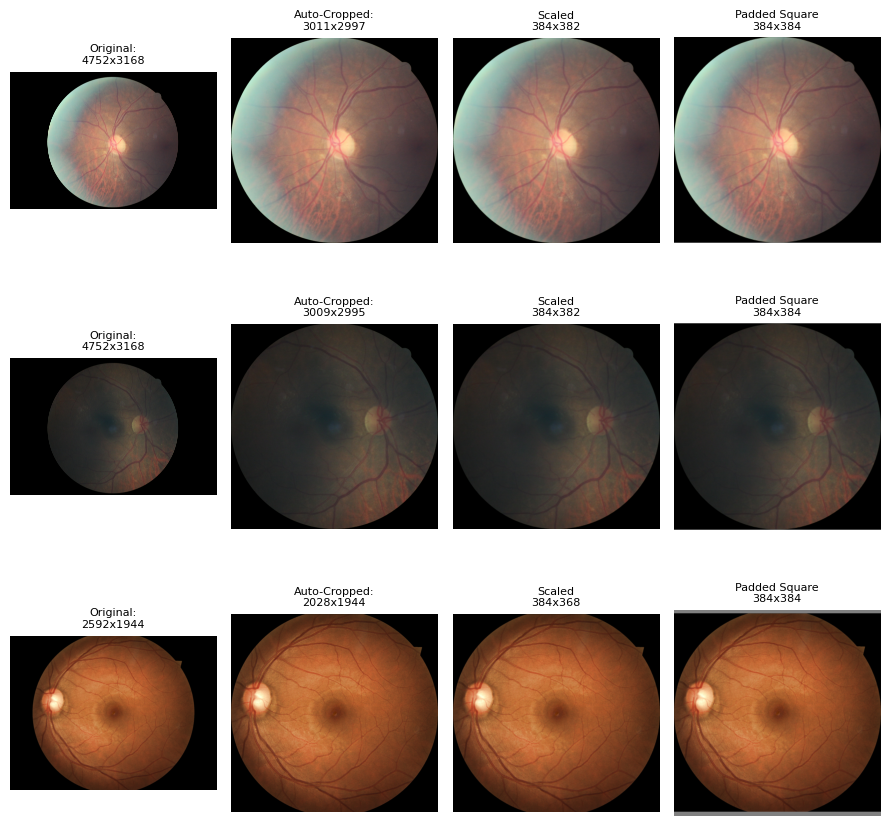

In [4]:
# Auto Crop: Remove Black Borders
def auto_crop(img, tol=10):
    # Convert image to grayscale for easier thresholding
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Create mask of pixels above tolerance (non-black region)
    mask = gray > tol
    
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    if not np.any(rows) or not np.any(cols): return img
    
    # Get bounding box coordinates
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    # Crop image to bounding box
    return img[rmin:rmax+1, cmin:cmax+1]

# Scale Radius: Normalize Eye Size
def scale_radius(img, target_scale=192):
    # Convert RGB image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Extract middle row to estimate eye diameter
    middle_row_sum = gray[gray.shape[0] // 2, :]
    
    # Count pixels belonging to eye region
    eye_pixels = (middle_row_sum > middle_row_sum.mean() / 10).sum()

    # Estimate radius
    r = eye_pixels / 2
    if r == 0: return img 
    # Compute scaling factor
    s = target_scale / r

    # Resize image proportionally
    return cv2.resize(img, (0, 0), fx=s, fy=s, interpolation=cv2.INTER_AREA)

# Square Padding: Standardize Input Shape
def square_pad(img, padding_color=128):
    # Get current image dimensions
    h, w = img.shape[:2]
    
    # Determine size of square canvas
    side = max(h, w)
    
    # Create square background filled with gray color
    padded_img = np.full((side, side, 3), padding_color, dtype=np.uint8)
    
    # Compute offsets to center the image
    top = (side - h) // 2
    left = (side - w) // 2
    
    # Place original image onto padded canvas
    padded_img[top:top+h, left:left+w] = img
    
    return padded_img

# Demonstration
image_folder = 'sample/' 
filenames = [f for f in os.listdir(image_folder) if f.endswith('.jpeg')][:3]

fig, axes = plt.subplots(3, 4, figsize=(9, 9))

for i, fname in enumerate(filenames):
    # Read image using OpenCV (BGR format)
    raw_bgr = cv2.imread(os.path.join(image_folder, fname))
    # Convert to RGB for correct visualization
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    
    # Auto Crop
    cropped_bgr = auto_crop(raw_bgr)
    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
    
    # Scale Radius
    scaled_rgb = scale_radius(cropped_rgb, target_scale=192)

    # Square Padding
    padded_rgb = square_pad(scaled_rgb)
    
    # Visualization

    # Original image
    axes[i, 0].imshow(raw_rgb)
    axes[i, 0].set_title(f"Original:\n{raw_rgb.shape[1]}x{raw_rgb.shape[0]}", fontsize=8)
    axes[i, 0].axis('off')

    # Cropped image
    axes[i, 1].imshow(cropped_rgb)
    axes[i, 1].set_title(f"Auto-Cropped:\n{cropped_rgb.shape[1]}x{cropped_rgb.shape[0]}", fontsize=8)
    axes[i, 1].axis('off')

    # Scaled image
    axes[i, 2].imshow(scaled_rgb)
    axes[i, 2].set_title(f"Scaled\n{scaled_rgb.shape[1]}x{scaled_rgb.shape[0]}", fontsize=8)
    axes[i, 2].axis('off')

    # Final padded image
    axes[i, 3].imshow(padded_rgb)
    axes[i, 3].set_title(f"Padded Square\n{padded_rgb.shape[1]}x{padded_rgb.shape[0]}", fontsize=8)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

**IV.	Ben Graham Contrast Enhancement:**

Some images were hazy, others have an orange tint, and in some cases, the center is bright while the edges are dark, which can make it harder to see small but important features, like microaneurysms or tiny haemorrhages. A local contrast enhancement technique called Ben Graham's method was applied to help highlight important features such as blood vessels and lesions, making them more visible for the model. This involves subtracting a blurred version of the image to remove the local average brightness. The result is that blood vessels and lesions stand out more clearly, improving the visibility of the features.

**V.	Circular Masking:**

After the Ben Graham enhancement, some unwanted effects appeared around the edges of the images. To remove this, everything outside the main circular retinal area was covered with a gray background. This ensures that the model only looks at the relevant part of the image and ignores any misleading edges.


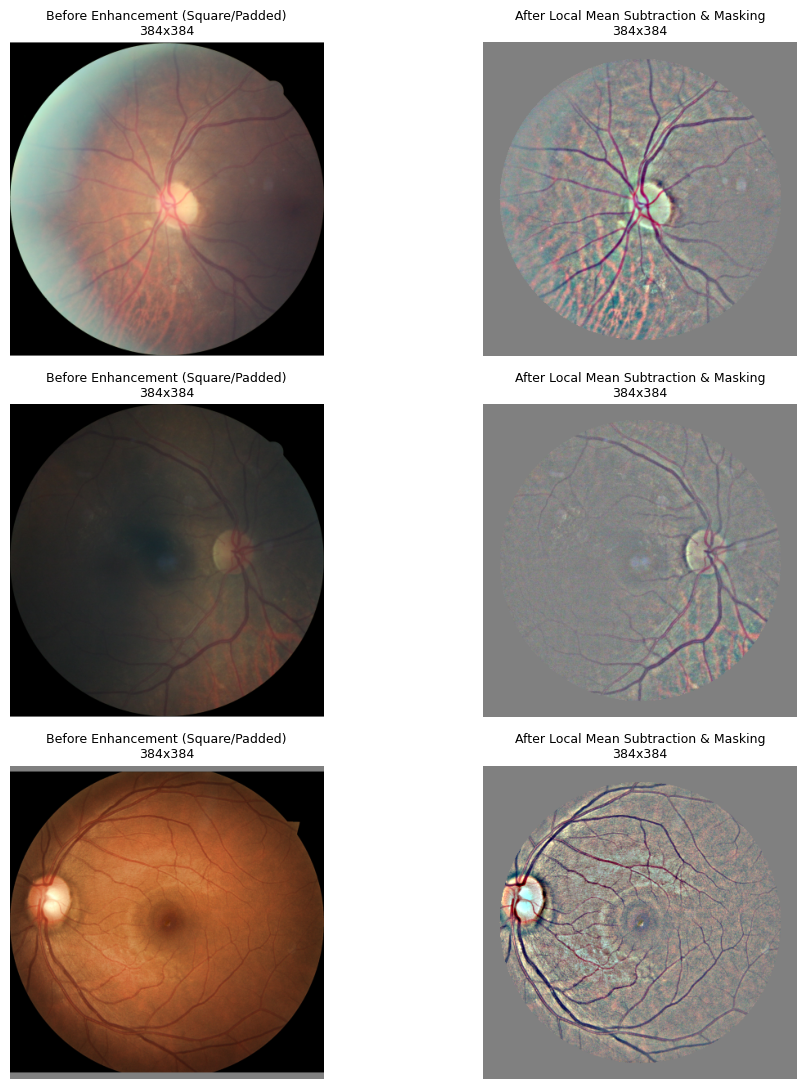

In [5]:
# Ben Graham Enhancement
def ben_graham_enhancement(img, scale=300):
    # Apply Gaussian blur to estimate local illumination (low-frequency component)
    blurred = cv2.GaussianBlur(img, (0, 0), scale / 30)
    
    # Enhance contrast by subtracting local average
    enhanced = cv2.addWeighted(img, 4, blurred, -3.9, 128)

    # Normalize pixel values to full 0–255 range
    enhanced = cv2.normalize(
        enhanced, None, alpha=0, beta=255, 
        norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )
    
    # Circular Mask (Focus on Retina Region)
    # Create empty mask
    mask = np.zeros(enhanced.shape, dtype=np.uint8)
    
    # Get image dimensions
    h, w = enhanced.shape[:2]
    
    # Define center and radius of circular region
    center = (w // 2, h // 2)
    radius = int(scale * 0.9)  # Keep ~90% of retinal region
    
    # Draw filled circle mask
    cv2.circle(mask, center, radius, (1, 1, 1), -1, 8, 0)
    
    # Apply mask: keep retina, suppress background with gray (128)
    final_output = enhanced * mask + 128 * (1 - mask)
    
    return final_output

# Demonstration
fig, axes = plt.subplots(3, 2, figsize=(11, 11))

for i, fname in enumerate(filenames):

    # Load original image (BGR → RGB)
    raw_bgr = cv2.imread(os.path.join(image_folder, fname))
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    
    cropped_bgr = auto_crop(raw_bgr)
    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
    scaled_rgb = scale_radius(cropped_rgb, target_scale=192)
    padded_rgb = square_pad(scaled_rgb)
    
    # Ben Graham Enhancement
    final_result = ben_graham_enhancement(padded_rgb, scale=192)
    
    # Visualization

    # Before enhancement
    axes[i, 0].imshow(padded_rgb)
    axes[i, 0].set_title(f"Before Enhancement (Square/Padded)\n{padded_rgb.shape[1]}x{padded_rgb.shape[0]}", fontsize=9)
    axes[i, 0].axis('off')

    # After enhancement
    axes[i, 1].imshow(final_result)
    axes[i, 1].set_title(f"After Local Mean Subtraction & Masking\n{padded_rgb.shape[1]}x{padded_rgb.shape[0]}", fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()